Saved → ner_comparison.png


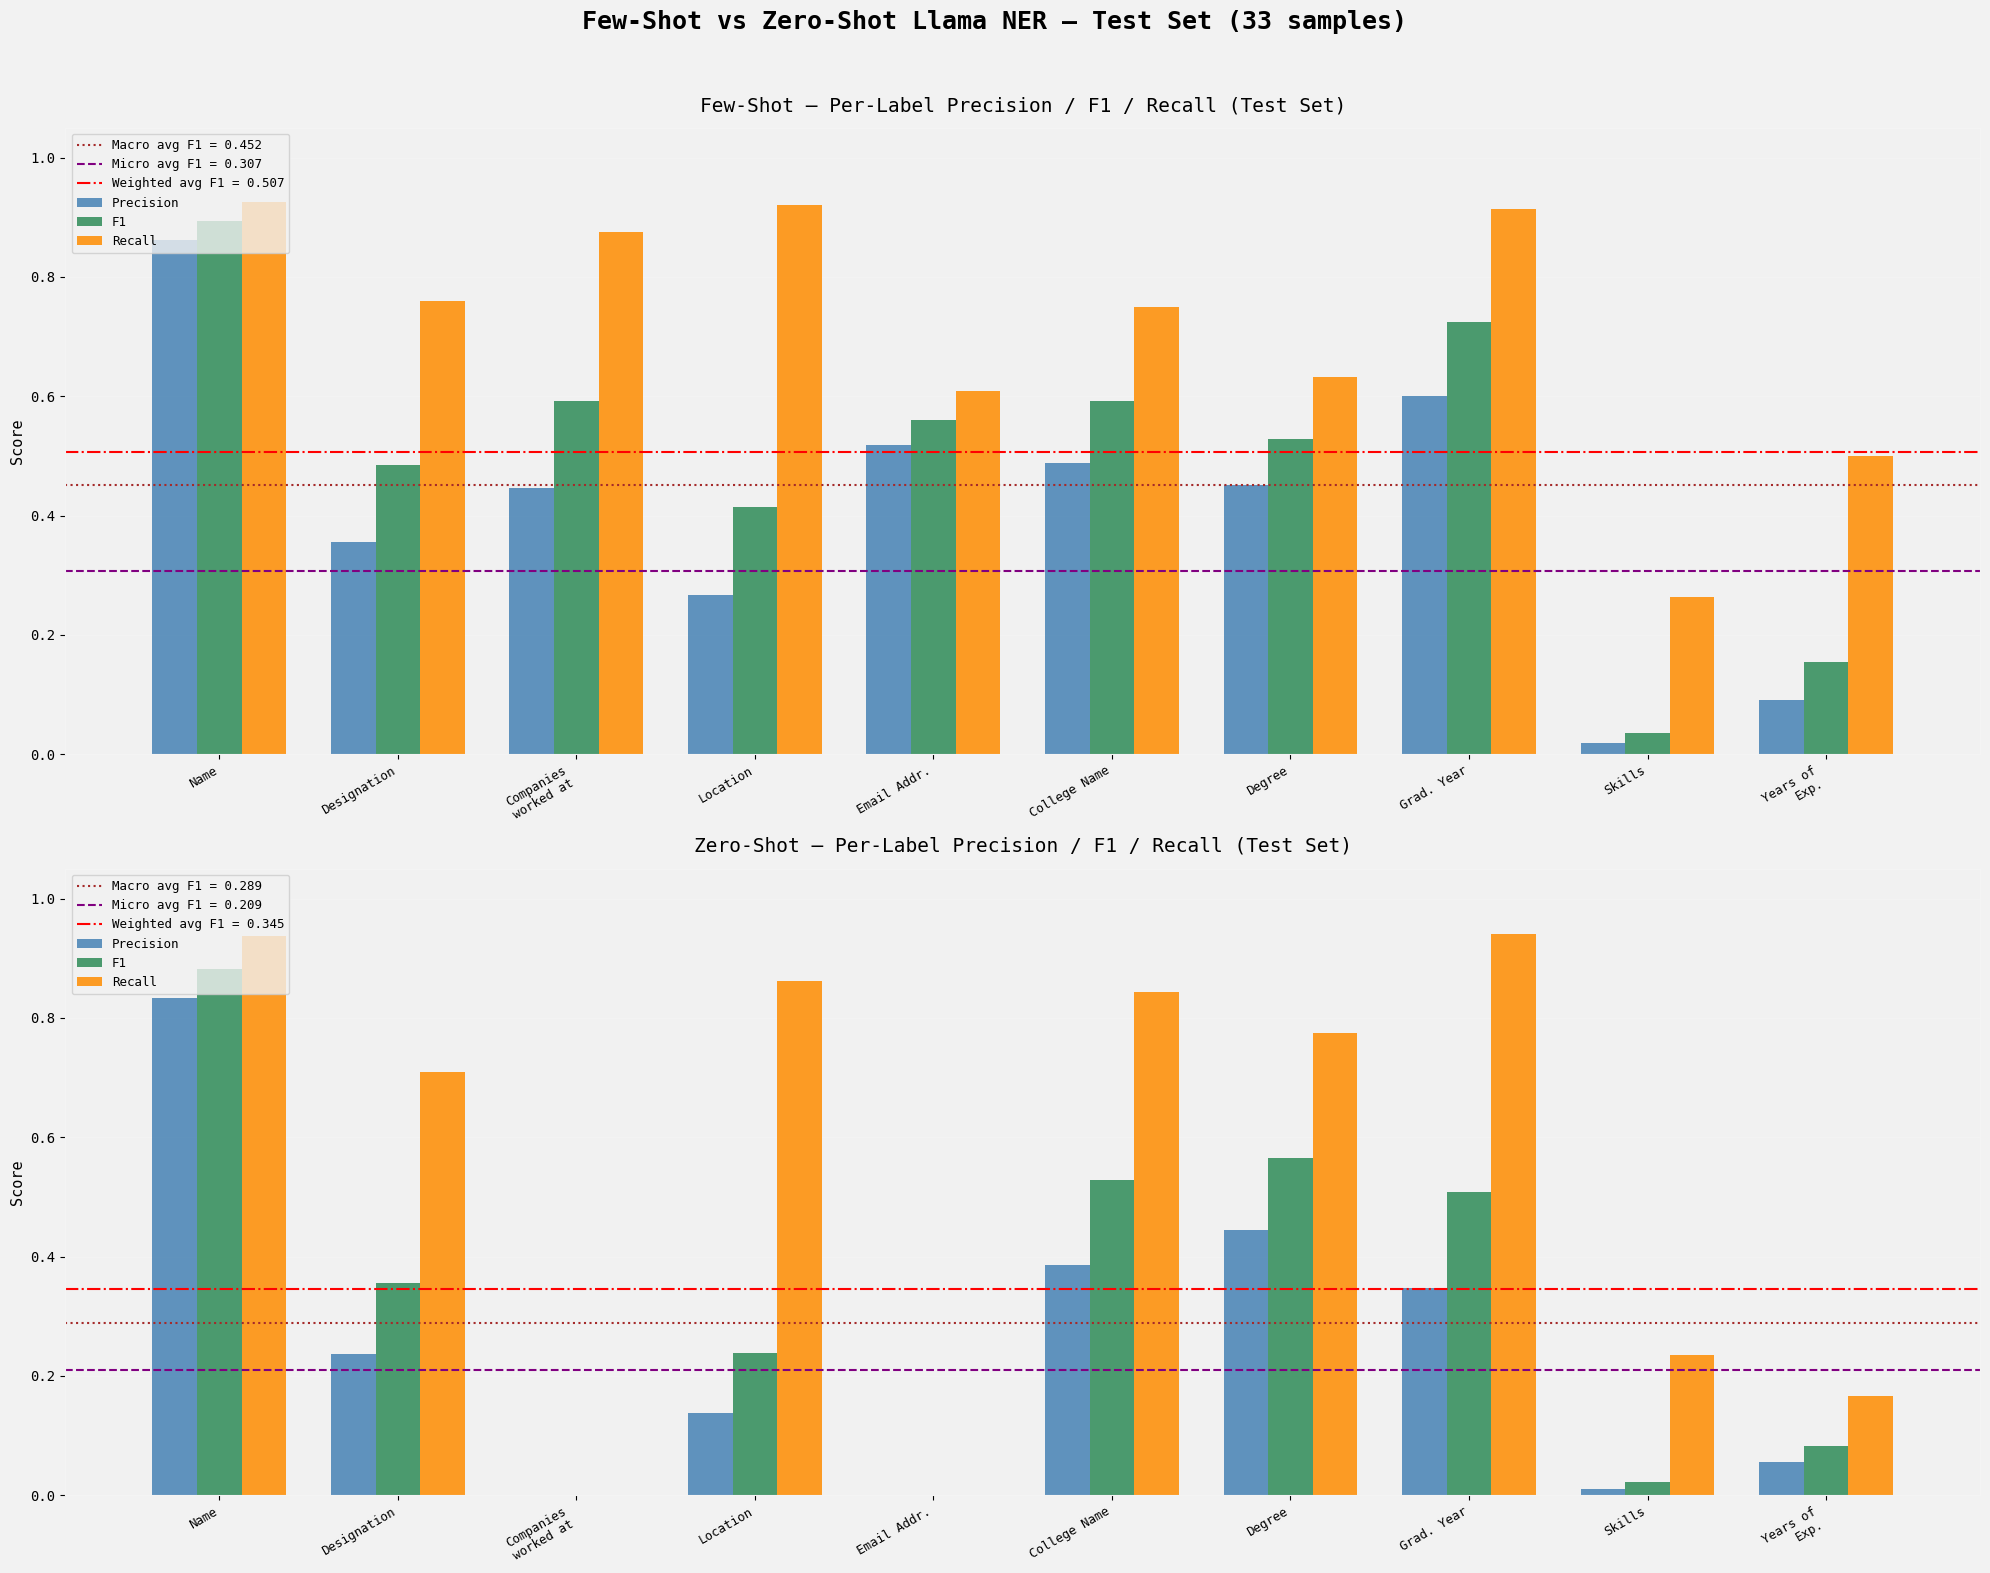

In [7]:
"""
NER Comparison: Few-Shot vs Zero-Shot Llama — Test Set (33 samples)
All data is embedded. Run with: python ner_comparison.py
Requires: matplotlib, numpy
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ──────────────────────────────────────────────
# DATA
# ──────────────────────────────────────────────

labels = [
    "Name",
    "Designation",
    "Companies worked at",
    "Location",
    "Email Address",
    "College Name",
    "Degree",
    "Graduation Year",
    "Skills",
    "Years of Experience",
]

few_shot = {
    "TP": [25, 22, 21, 23, 14, 21, 19, 21, 10, 1],
    "FP": [4,  40, 26, 63, 13, 22, 23, 14, 512, 10],
    "FN": [2,   7,  3,  2,  9,  7, 11,  2,  28,  1],
    "Precision": [0.862, 0.355, 0.447, 0.267, 0.519, 0.488, 0.452, 0.600, 0.019, 0.091],
    "Recall":    [0.926, 0.759, 0.875, 0.920, 0.609, 0.750, 0.633, 0.913, 0.263, 0.500],
    "F1":        [0.893, 0.484, 0.592, 0.414, 0.560, 0.592, 0.528, 0.724, 0.036, 0.154],
    "Macro_F1":  0.452,
    "Micro_F1":  0.299,
    "Macro_Precision": 0.373,
    "Macro_Recall":    0.650,
}

zero_shot = {
    "TP": [30, 22,  0, 25,  0, 27, 24, 16,  8,  1],
    "FP": [6,  71,  0, 156, 1, 43, 30, 30, 694, 17],
    "FN": [2,   9, 26,  4, 24,  5,  7,  1,  26,  5],
    "Precision": [0.833, 0.237, 0.000, 0.138, 0.000, 0.386, 0.444, 0.348, 0.011, 0.056],
    "Recall":    [0.938, 0.710, 0.000, 0.862, 0.000, 0.844, 0.774, 0.941, 0.235, 0.167],
    "F1":        [0.882, 0.355, 0.000, 0.238, 0.000, 0.529, 0.565, 0.508, 0.022, 0.083],
    "Macro_F1":  0.289,
    "Micro_F1":  None,  # not reported
    "Macro_Precision": 0.223,
    "Macro_Recall":    0.497,
}

# ──────────────────────────────────────────────
# STYLE
# ──────────────────────────────────────────────

BG        = "#F2F2F2"
PANEL     = "#F1F1F1"
FEW_COLOR = "#6C8EF5"   # soft blue  — few-shot
ZER_COLOR = "#F5A623"   # amber      — zero-shot
GRID_CLR  = "#F4F4F4"
TEXT_CLR  = "#000000"
MUTED     = "#000000"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID_CLR,
    "axes.labelcolor":   TEXT_CLR,
    "axes.titlecolor":   TEXT_CLR,
    "xtick.color":       MUTED,
    "ytick.color":       TEXT_CLR,
    "text.color":        TEXT_CLR,
    "grid.color":        GRID_CLR,
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
})

x      = np.arange(len(labels))
width  = 0.35
short  = [l.replace("Companies worked at", "Companies\nworked at")
           .replace("Years of Experience", "Years of\nExp.")
           .replace("Graduation Year", "Grad. Year")
           .replace("Email Address", "Email Addr.")
           .replace("College Name", "College Name")
           for l in labels]

def compute_avg_scores(data):
    tp = np.array(data["TP"], dtype=float)
    fp = np.array(data["FP"], dtype=float)
    fn = np.array(data["FN"], dtype=float)
    support = tp + fn
    micro_tp = tp.sum()
    micro_fp = fp.sum()
    micro_fn = fn.sum()
    micro_precision = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
    micro_recall = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
    micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0
    weighted_precision = (np.array(data["Precision"], dtype=float) * support).sum() / support.sum() if support.sum() > 0 else 0.0
    weighted_recall = (np.array(data["Recall"], dtype=float) * support).sum() / support.sum() if support.sum() > 0 else 0.0
    weighted_f1 = (np.array(data["F1"], dtype=float) * support).sum() / support.sum() if support.sum() > 0 else 0.0
    return {
        "micro_f1": micro_f1,
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "weighted_f1": weighted_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
    }

few_stats = compute_avg_scores(few_shot)
zero_stats = compute_avg_scores(zero_shot)

fig, axes = plt.subplots(2, 1, figsize=(20, 16), facecolor=BG)
fig.suptitle(
    "Few-Shot vs Zero-Shot Llama NER — Test Set (33 samples)",
    fontsize=18, fontweight="bold", color=TEXT_CLR, y=0.98
)

for ax, data, stats, title, color in [
    (axes[0], few_shot, few_stats, 'Few-Shot', FEW_COLOR),
    (axes[1], zero_shot, zero_stats, 'Zero-Shot', ZER_COLOR),
]:
    x_labels = [l.replace("Companies worked at", "Companies\nworked at")
                .replace("Years of Experience", "Years of\nExp.")
                .replace("Graduation Year", "Grad. Year")
                .replace("Email Address", "Email Addr.")
                for l in labels]
    x_inds = np.arange(len(labels))
    w = 0.25

    p = np.array(data["Precision"], dtype=float)
    r = np.array(data["Recall"], dtype=float)
    f = np.array(data["F1"], dtype=float)

    ax.bar(x_inds - w, p, width=w, label='Precision', color='steelblue', alpha=0.85)
    ax.bar(x_inds, f, width=w, label='F1', color='seagreen', alpha=0.85)
    ax.bar(x_inds + w, r, width=w, label='Recall', color='darkorange', alpha=0.85)

    ax.set_title(f'{title} — Per-Label Precision / F1 / Recall (Test Set)', fontsize=14, pad=12)
    ax.set_xticks(x_inds)
    ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score', fontsize=11, color=TEXT_CLR)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)

    ax.axhline(data.get('Macro_F1', 0), color='brown', linestyle=':', linewidth=1.5,
               label=f'Macro avg F1 = {data.get("Macro_F1", 0):.3f}')
    ax.axhline(stats['micro_f1'], color='purple', linestyle='--', linewidth=1.5,
               label=f'Micro avg F1 = {stats["micro_f1"]:.3f}')
    ax.axhline(stats['weighted_f1'], color='red', linestyle='-.', linewidth=1.5,
               label=f'Weighted avg F1 = {stats["weighted_f1"]:.3f}')

    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
out = "ner_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"Saved → {out}")
plt.show()